In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## Load dataset

In [ ]:
def load_dataset(dataset_path, batch_size=32, test_split=0.2):

    train_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=30),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # center crop
    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    full_dataset = torchvision.datasets.ImageFolder(dataset_path, transform=train_transform)
    train_size = int((1 - test_split) * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    test_dataset.dataset = torchvision.datasets.ImageFolder(dataset_path, transform=test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    num_classes = len(full_dataset.classes)
    class_names = full_dataset.classes
    
    print(f"Dataset caricato:")
    print(f"- Numero di classi: {num_classes}")
    print(f"- Classi: {class_names}")
    print(f"- Training samples: {len(train_dataset)}")
    print(f"- Test samples: {len(test_dataset)}")
    
    return train_loader, test_loader, num_classes, class_names

## Model

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, num_classes, pretrained=True, freeze_backbone=False, dropout=0.2):
        super(VisionTransformer, self).__init__()
        
        try:
            if pretrained:
                weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1
                self.backbone = torchvision.models.vit_b_16(weights=weights)
            else:
                self.backbone = torchvision.models.vit_b_16(weights=None)
            
            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False
            
            in_features = self.backbone.heads.head.in_features
            self.backbone.heads.head = nn.Sequential(
                nn.LayerNorm(in_features),
                nn.Dropout(dropout),
                nn.Linear(in_features, num_classes)
            )
        
        except Exception as e:
            print(f"[WARN] VisionTransformer non disponibile ({e}), uso ResNet34 fallback")
            if pretrained:
                weights = torchvision.models.ResNet34_Weights.IMAGENET1K_V1
                self.backbone = torchvision.models.resnet34(weights=weights)
            else:
                self.backbone = torchvision.models.resnet34(weights=None)
            
            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False
            
            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Sequential(
                nn.LayerNorm(in_features),
                nn.Dropout(dropout),
                nn.Linear(in_features, num_classes)
            )

    def forward(self, x):
        return self.backbone(x)

## Test

In [4]:
def test_model(model, test_loader, verbose=True):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    accuracy = 100. * correct / total
    
    if verbose:
        print(f'Test Accuracy: {accuracy:.2f}%')
        print(f'Test Error: {100 - accuracy:.2f}%')
    
    return accuracy

## Train

In [ ]:
def train_vit_model(model, train_loader, test_loader, epochs=50, lr=3e-4, weight_decay=0.05, method_name="Vision Transformer"):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = epochs * len(train_loader)
    warmup_steps = int(0.1 * total_steps)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps - warmup_steps)
    
    train_losses, train_accs, test_accs = [], [], []
    best_acc = 0.0
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_idx, (data, target) in enumerate(pbar):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            
            current_step = epoch * len(train_loader) + batch_idx
            if current_step > warmup_steps:
                scheduler.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total_train += target.size(0)
            correct_train += predicted.eq(target).sum().item()
            
            pbar.set_postfix({
                'Loss': f'{running_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })
        
        train_acc = 100. * correct_train / total_train
        train_loss = running_loss / len(train_loader)
        test_acc = test_model(model, test_loader, verbose=False)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), f'best_{method_name.lower().replace(" ", "_")}_model.pth')
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f"Training completato in {training_time:.2f} secondi")
    print(f"Migliore accuratezza: {best_acc:.2f}%")
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_accs': test_accs,
        'best_acc': best_acc,
        'training_time': training_time,
        'final_error': 100 - best_acc
    }

## Plot

In [6]:
def plot_training_curves(results_dict, class_names):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Training Loss
    ax = axes[0, 0]
    for method_name, results in results_dict.items():
        epochs = range(1, len(results['train_losses']) + 1)
        ax.plot(epochs, results['train_losses'], label=method_name, linewidth=2)
    ax.set_title('Training Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Training Accuracy
    ax = axes[0, 1]
    for method_name, results in results_dict.items():
        epochs = range(1, len(results['train_accs']) + 1)
        ax.plot(epochs, results['train_accs'], label=method_name, linewidth=2)
    ax.set_title('Training Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Test Accuracy
    ax = axes[1, 0]
    for method_name, results in results_dict.items():
        epochs = range(1, len(results['test_accs']) + 1)
        ax.plot(epochs, results['test_accs'], label=method_name, linewidth=2)
    ax.set_title('Test Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Comparison Bar Chart
    ax = axes[1, 1]
    methods = list(results_dict.keys())
    best_accs = [results_dict[method]['best_acc'] for method in methods]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    bars = ax.bar(methods, best_accs, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title('Best Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)
    
    # Aggiungi valori sulle barre
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_results_table(results_dict):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')
    
    # Prepara i dati per la tabella
    table_data = []
    headers = ['Method', 'Best Accuracy (%)', 'Final Error (%)', 'Training Time (s)', 'Parameters']
    
    for method_name, results in results_dict.items():
        row = [
            method_name,
            f"{results['best_acc']:.1f}%",
            f"{results['final_error']:.1f}%",
            f"{results['training_time']:.0f}s",
            "N/A"
        ]
        table_data.append(row)
    
    # Crea la tabella
    table = ax.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2)
    
    # Styling
    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Colora le righe alternativamente
    for i in range(1, len(table_data) + 1):
        for j in range(len(headers)):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#F5F5F5')
    
    plt.title('Results Summary', fontsize=16, fontweight='bold', pad=20)
    plt.show()

ESPERIMENTO DI CLASSIFICAZIONE CON VISION TRANSFORMER OTTIMIZZATO
Caricamento dataset...
Dataset caricato:
- Numero di classi: 25
- Classi: ['BEANS', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'FISH', 'FLOUR', 'HONEY', 'JAM', 'JUICE', 'MILK', 'NUTS', 'OIL', 'PASTA', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'TEA', 'TOMATO_SAUCE', 'VINEGAR', 'WATER']
- Training samples: 3957
- Test samples: 990

=== Training Vision Transformer ===


Epoch 1/100: 100%|██████████| 124/124 [00:59<00:00,  2.10it/s, Loss=3.2718, Acc=7.13%]


Epoch 1: Train Loss: 3.2718, Train Acc: 7.13%, Test Acc: 14.14%


Epoch 2/100: 100%|██████████| 124/124 [00:58<00:00,  2.13it/s, Loss=3.1013, Acc=10.29%]


Epoch 2: Train Loss: 3.1013, Train Acc: 10.29%, Test Acc: 18.99%


...

Epoch 98: Train Loss: 0.2239, Train Acc: 93.48%, Test Acc: 77.58%


Epoch 99/100: 100%|██████████| 124/124 [00:54<00:00,  2.26it/s, Loss=0.2282, Acc=93.78%]


Epoch 99: Train Loss: 0.2282, Train Acc: 93.78%, Test Acc: 77.68%


Epoch 100/100: 100%|██████████| 124/124 [00:54<00:00,  2.26it/s, Loss=0.2626, Acc=92.90%]


Epoch 100: Train Loss: 0.2626, Train Acc: 92.90%, Test Acc: 77.68%
Training completato in 6753.64 secondi
Migliore accuratezza: 77.68%

RISULTATI FINALI
Migliore Accuratezza: 77.7%
Errore Finale: 22.3%
Tempo di Training: 6754s


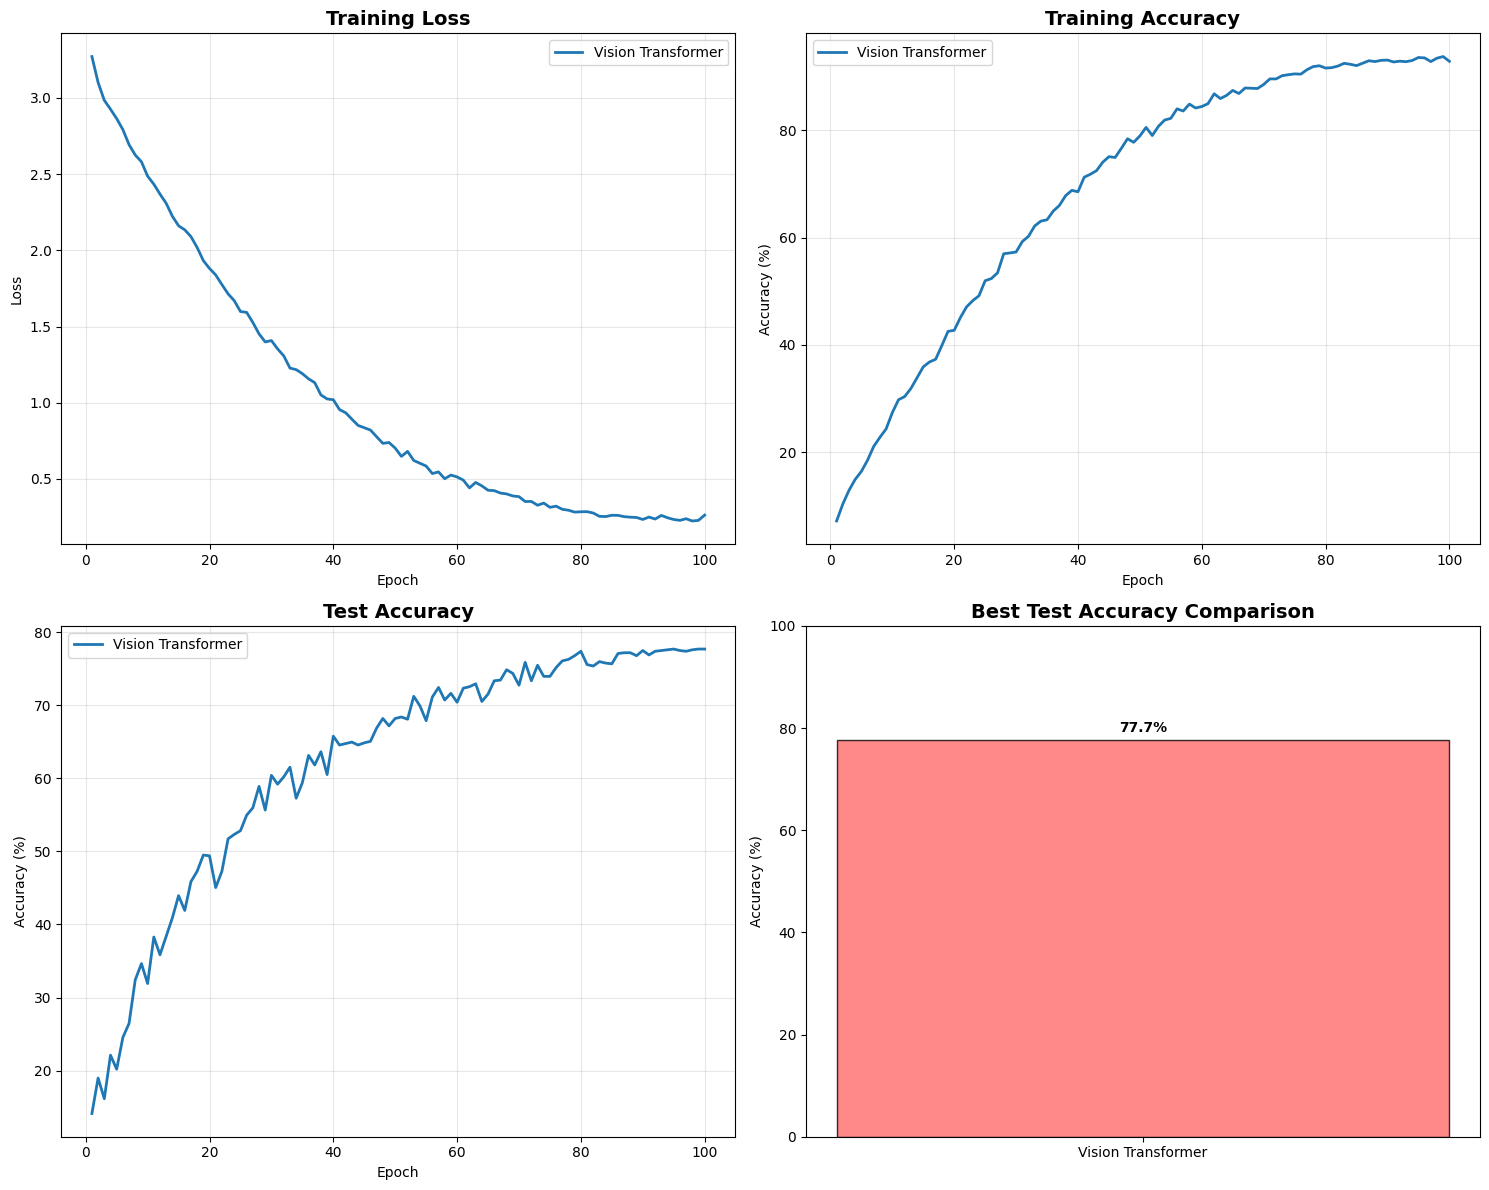

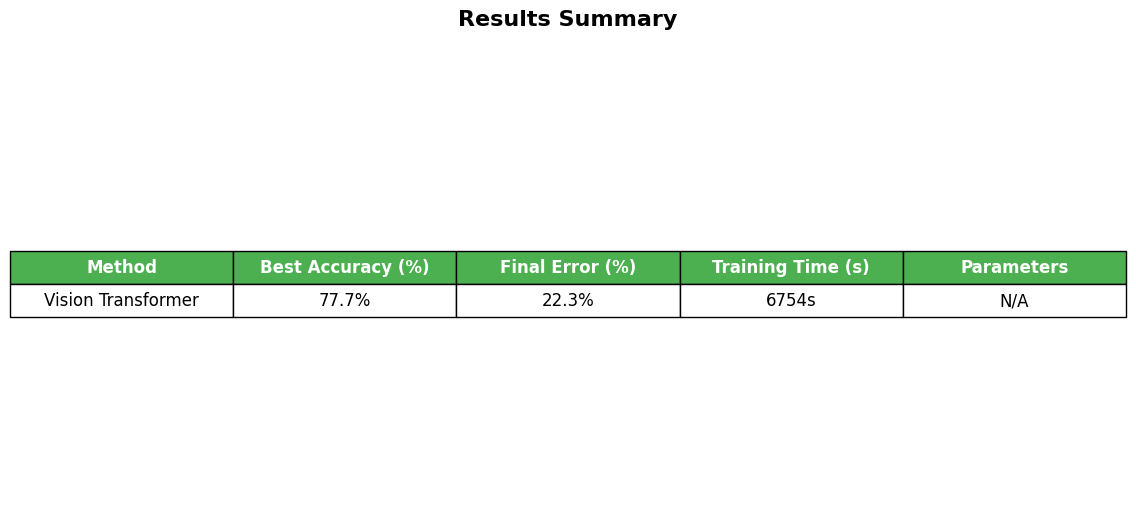


Esperimento completato!
Il modello migliore è stato salvato come 'best_vision_transformer_model.pth'


In [ ]:
def main():
    dataset_path = "dataset"
    
    print("Caricamento dataset...")
    train_loader, test_loader, num_classes, class_names = load_dataset(
        dataset_path, batch_size=32, test_split=0.2
    )
    
    model = VisionTransformer(
        num_classes=num_classes,
        pretrained=True,
        freeze_backbone=False,
        dropout=0.2
    ).to(device)
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    results = train_vit_model(
        model,
        train_loader,
        test_loader,
        epochs=100,
        lr=3e-4,
        method_name="Vision Transformer"
    )
    
    results_dict = {"Vision Transformer": results}
    
    print("\n" + "="*80)
    print("RISULTATI FINALI")
    print("="*80)
    print(f"Migliore Accuratezza: {results['best_acc']:.1f}%")
    print(f"Errore Finale: {results['final_error']:.1f}%")
    print(f"Tempo di Training: {results['training_time']:.0f}s")
    
    plot_training_curves(results_dict, class_names)
    plot_results_table(results_dict)

main()